# From Focus to Interaction Structure

This notebook summarizes how effect size (Cramér’s V) and statistical evidence (p-values) evolve as progressively richer interaction structures are introduced. Across both the combined and goal split subgroups, the strongest patterns emerge when focus is interpreted jointly with agency rather than in isolation. In addition, furhter differences are explored between goal contexts(frequent and non_frequent) and no goal contexts as a result of previous EDA, realising how those differ from the combined dataset separately. 

After looking into consequent reversibility as a theoretical new variable that could be taken on board with the intention to see what else could be adding complexity to the structure's resolution, it has finally been discarded given that it overlaps with goal type.

Import libraries

In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Summary Results: Combined vs. Goals

1. Figure 1: χ² statistics across effect structures
2. Figure 2: Inferential evidence across effect structures
3. Figure 3: Association strength across effect structures

In [92]:
effect_type = ["Focus", "Goal x Focus", "Agency x Focus", "Goal x Agency x Focus"]

chi_sq_combined = [1.866, 13.718, 12.364, 32.111]
chi_sq_goals = [5.437, 11.188, 17.590, 26.419]

p_combined = [0.3934, 0.1863, 0.0543, 0.0755]
p_goals = [0.0660, 0.0827, 0.0073, 0.0229]

V_combined = [0.098, 0.188, 0.178, 0.287]
V_goals = [0.204, 0.207, 0.259, 0.318]

## Figure 1: χ² statistics across effect structures

In [93]:

chi_sq_df = pd.DataFrame({"effect_type": effect_type, "chi_sq_combined": chi_sq_combined, "chi_sq_goals": chi_sq_goals})
chi_sq_df.set_index("effect_type")

,chi_sq_combined,chi_sq_goals
effect_type,,
Focus,1.866,5.437
Goal x Focus,13.718,11.188
Agency x Focus,12.364,17.590
Goal x Agency x Focus,32.111,26.419


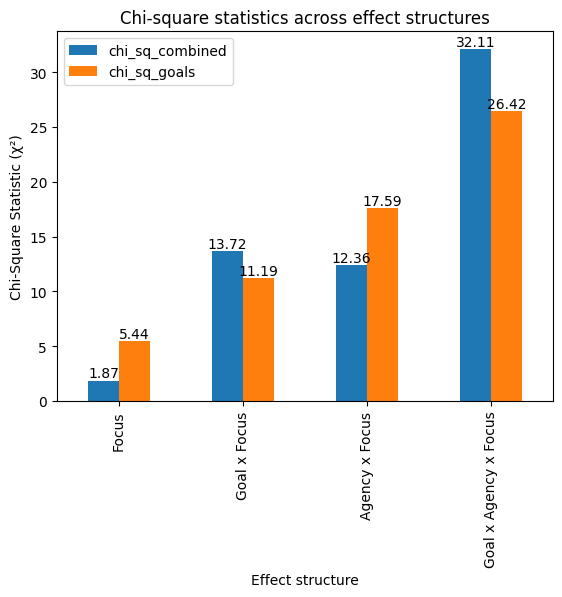

In [94]:
ax = chi_sq_df.plot(x = "effect_type", y = ["chi_sq_combined", "chi_sq_goals"], kind = "bar")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.title("Chi-square statistics across effect structures")
plt.xlabel("Effect structure")
plt.ylabel("Chi-Square Statistic (χ²)")
plt.show()



## Figure 2: Inferential evidence across effect structures

In [95]:
p_value_df = pd.DataFrame({"effect_type": effect_type, "p_combined": p_combined, "p_goals": p_goals})
p_value_df.set_index("effect_type")

,p_combined,p_goals
effect_type,,
Focus,0.3934,0.0660
Goal x Focus,0.1863,0.0827
Agency x Focus,0.0543,0.0073
Goal x Agency x Focus,0.0755,0.0229


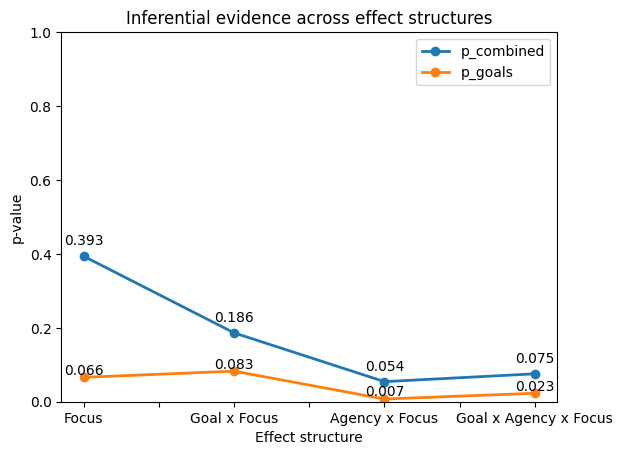

In [96]:
ax = p_value_df.plot(
    x="effect_type",
    y=["p_combined", "p_goals"],
    marker="o",
    linewidth=2
    )

for line in ax.lines:
    x_data = line.get_xdata()
    y_data = line.get_ydata()

    if line.get_label() == "p_combined":
        offset = (0, 8)
    else:
        offset = (0, 2)

    for x, y in zip(x_data, y_data):
        ax.annotate(
            f"{y:.3f}",
            (x, y),
            textcoords="offset points",
            xytext=offset,
            ha="center"
            )

plt.title("Inferential evidence across effect structures")
plt.xlabel("Effect structure")
plt.ylabel("p-value")
plt.ylim(0, 1)
plt.show()

## Figure 3: Association strength across effect structure

In [97]:
V_df = pd.DataFrame({"effect_type": effect_type, "V_combined": V_combined, "V_goals": V_goals})
V_df.set_index("effect_type")

,V_combined,V_goals
effect_type,,
Focus,0.098,0.204
Goal x Focus,0.188,0.207
Agency x Focus,0.178,0.259
Goal x Agency x Focus,0.287,0.318


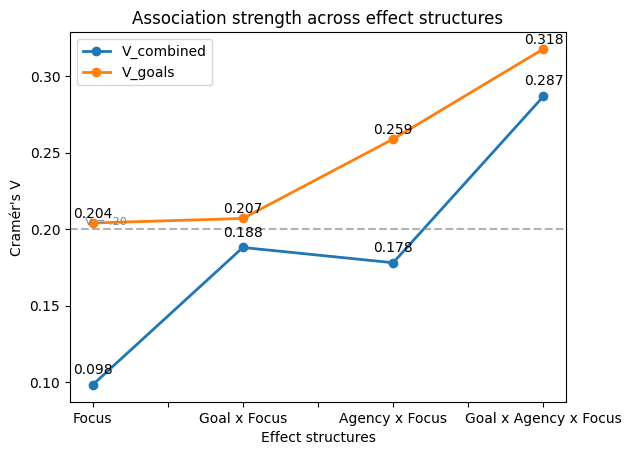

In [98]:
ax = V_df.plot(
    x="effect_type",
    y=["V_combined", "V_goals"],
    marker="o",
    linewidth=2
    )

for line in ax.lines:
    x_data = line.get_xdata()
    y_data = line.get_ydata()

    if line.get_label() == "V_combined":
        offset = (0, 8)
    else:
        offset = (0, 4)

    for x, y in zip(x_data, y_data):
        ax.annotate(
            f"{y:.3f}",
            (x, y),
            textcoords="offset points",
            xytext=offset,
            ha="center"
            )

plt.title("Association strength across effect structures")

plt.axhline(
     y=0.20,
     linestyle="--",
     alpha=0.6,
     color = "grey"
     )

plt.text(
    -0.05,
    0.203,
    'V = .20',
    fontsize = 8,
    color="grey"
)

plt.xlabel("Effect structures")
plt.ylabel("Cramér's V")
plt.show()

## Interpretation

- Focus only becomes meaningful only after the goal behavioural split:
    - Combined: V = 0.098, p = 0.3934
    - Goals: V = 0.204, p = 0.0660
    This is a substantial change. The Goals subset has fewer observations, yet the association roughly doubles in standardized magnitude and moves much closer to inferential detectability. Therefore, Focus on its own is not generally weak; its role is obscured when goal-directed and no-goal behaviour are mixed. 

- Goal x Focus adds only a little beyond Focus within Goal behaviour data:
    - Goals: V = 0.207, p = 0.0827
    This is interesting as Goal Type's contribution, even within goals, might not have so relevant a role as Focus or Agency. This is also coherent with what residuals keep showing: the distinction between goal-frequent and goal-non-frequent matters but it is not where the clearest structural gain occurs. Their difference depends heavily on the agency and perspective configuration. 

- Agency x Focus shows where the split reveals the mechanism:
    - Combined: V = 0.178, p = 0.0543
    - Goals: V = 0.259, p = 0.0073
    This is the real turning point. The effect size rises clearly, the association becomes statistically detectable (and the residual pattern became much more interpretable). What is observed so far is that explicit agency does not exert one uniform influence; its meaning changes according to whether participants emobidy the counterfactual or process it from an external perspective. It is a persepective conditioned agency.

- Goal x Agency x Focus has the largest effect size:
    - Combined: V = 0.287, p = 0.0755
    - Goals: V = 0.318, p = 0.0229
    The highest order structure with goals only produces the largest V and the goals only association is stronger and statistically detectable despite the small sample. However, the expected count is an issue: there is a strong and coherent descriptive association which is supported by a significant asymptotic chi-square result but it should be interpreted cautiously becuase of the amount of sparse cells.

Overall, once there is a goal to pursue, focus starts to matter; but its behavioural consequences are expressed especially through what explicit agency means from that perspective.

Removing no-goal behaviour revealed that the apparent Focus effect is organised principally through its relationship with Agency, and ultimately through the complete Goal Type × Agency × Focus structure

## Summary Results: Goals vs. No Goals

1. Figure 1: χ² statistics across effect structures
2. Figure 2: Inferential evidence across effect structures
3. Figure 3: Association strength across effect structures

In [99]:
effect_type = ["Focus", "Agency x Focus"]

chi_sq_combined = [1.866, 12.364]
chi_sq_goals = [5.437, 17.590]
chi_sq_no_goals = [1.983, 5.240]

p_combined = [0.3934, 0.0543]
p_goals = [0.0660, 0.0073]
p_no_goals = [0.3710, 0.5134]

V_combined = [0.098,  0.178]
V_goals = [0.204, 0.259]
V_no_goals = [0.176, 0.202]

## Figure 1: χ² statistics across effect structures

In [100]:
chi_sq_df = pd.DataFrame({"effect_type": effect_type, "chi_sq_combined": chi_sq_combined, "chi_sq_goals": chi_sq_goals, "chi_sq_no_goals": chi_sq_no_goals})
chi_sq_df.set_index("effect_type")

,chi_sq_combined,chi_sq_goals,chi_sq_no_goals
effect_type,,,
Focus,1.866,5.437,1.983
Agency x Focus,12.364,17.590,5.240


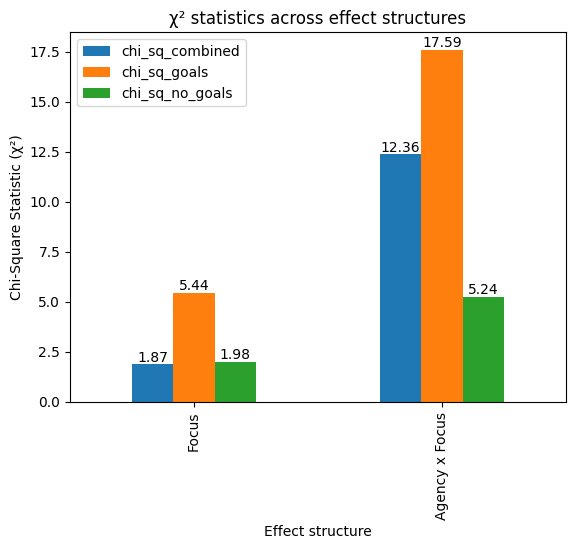

In [101]:
ax = chi_sq_df.plot(x = "effect_type", y = ["chi_sq_combined", "chi_sq_goals", "chi_sq_no_goals"], kind = "bar")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.title("χ² statistics across effect structures")
plt.xlabel("Effect structure")
plt.ylabel("Chi-Square Statistic (χ²)")
plt.show()

## Figure 2: Inferential evidence across effect structures

In [102]:
p_value_df = pd.DataFrame({"effect_type": effect_type, "p_combined": p_combined, "p_goals": p_goals, "p_no_goals": p_no_goals})
p_value_df.set_index("effect_type")

,p_combined,p_goals,p_no_goals
effect_type,,,
Focus,0.3934,0.0660,0.3710
Agency x Focus,0.0543,0.0073,0.5134


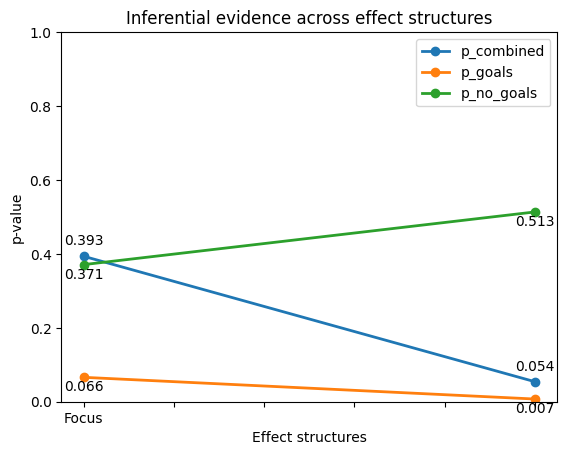

In [103]:
ax = p_value_df.plot(
    x="effect_type",
    y=["p_combined","p_goals", "p_no_goals"],
    marker="o",
    linewidth=2
    )

for line in ax.lines:
    x_data = line.get_xdata()
    y_data = line.get_ydata()

    if line.get_label() == "p_combined":
        offset = (0, 8)
    else:
        offset = (0, -10)

    for x, y in zip(x_data, y_data):
        ax.annotate(
            f"{y:.3f}",
            (x, y),
            textcoords="offset points",
            xytext=offset,
            ha="center"
            )

plt.title("Inferential evidence across effect structures")
plt.xlabel("Effect structures")
plt.ylabel("p-value")
plt.ylim(0, 1)
plt.show()

## Figure 3: Association strength across effect structures

In [104]:
V_df = pd.DataFrame({"effect_type": effect_type, "V_combined": V_combined,"V_goals": V_goals, "V_no_goals": V_no_goals})
V_df.set_index("effect_type")

,V_combined,V_goals,V_no_goals
effect_type,,,
Focus,0.098,0.204,0.176
Agency x Focus,0.178,0.259,0.202


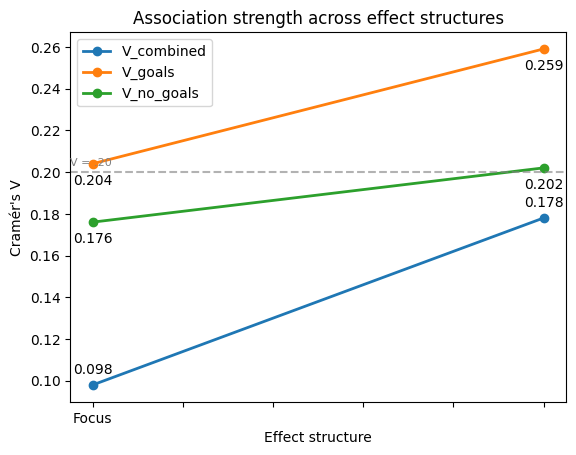

In [105]:
ax = V_df.plot(
    x="effect_type",
    y=["V_combined", "V_goals", "V_no_goals"],
    marker="o",
    linewidth=2
    )

for line in ax.lines:
    x_data = line.get_xdata()
    y_data = line.get_ydata()

    if line.get_label() == "V_combined":
        offset = (0, 8)
    else:
        offset = (0, -15)

    for x, y in zip(x_data, y_data):
        ax.annotate(
            f"{y:.3f}",
            (x, y),
            textcoords="offset points",
            xytext=offset,
            ha="center"
            )

plt.title("Association strength across effect structures")

plt.axhline(
     y=0.20,
     linestyle="--",
     alpha=0.6,
     color = "grey"
     )

plt.text(
    -0.05,
    0.203,
    'V = .20',
    fontsize = 8,
    color="grey"
)

plt.xlabel("Effect structure")
plt.ylabel("Cramér's V")
plt.show()

## Interpretation

The share of observations left for no goals contexts as a sample is clearly not enough. Still, by seeing it together with the goal context and the combined dataset, we get a clearer picture of agency:

- X2:
    - Combined: 1.87 --> 12.36
    - Goals: 5.44 --> 17.59: respectable increase.
    - No goals: 1.98 --> 5.24: nothing dramatic.
While we can's say that much about no goals, the differences between both groups confirms that agency matters because of goal contexts. 

- p-values:
    - Goals: 0.066 --> 0.007: the evidence stregthens when agency is introduced.
    - No Goals: 0.37 --> 0.51: still random.
Agency only becomes informatie where it theoretically should, within goal contexts.

- Cramér's V:
    - Goals: 0.204 --> 0.259
    - No Goals: 0.176 --> 0.202
Agency changes the association, but the change in the association when there is not motivational context isn't that much. 

Agency is informative only when there is a gola representation to attach to it.
